In [2]:
import anndata
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy
from matplotlib.pyplot import rc_context



In [8]:
# --- PLOTTING PARAMETERS ---

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
rc_params = {
	"font.family": "sans-serif", # "text.usetex": True,
	"font.serif" : ['Arial'], # "font.size" : 6,
	"font.weight" : "normal",
	'xtick.labelsize' : 5,
	'ytick.labelsize' : 5,
	'legend.fontsize' : 5,
	'axes.labelsize' : 6,
	'axes.linewidth': 0.8,
	'lines.linewidth' : 1
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
	"left"   :     0.2,
	'right' : 1.0,
	'bottom' : 0.15
}

In [4]:

# --- INIT ---

# get the user folder
user_folder = "/".join(os.getcwd().split("/")[:3])

# which data to use
head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % user_folder
hvg_to_use = 'connected'
cluster_resolution = 0.1

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)
reg_head_folder = '%s/bayesian_harmonic_reg' % clustering_folder
de_folder_out = '%s/de' % clustering_folder
marker_gene_dict_path = '%s/marker_gene_dict.txt' % (de_folder_out)



## SUBPANEL B
cluster visualization


In [5]:
# --- LOAD ADATA ---

adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [6]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])













/opt/miniconda3/envs/tempo/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


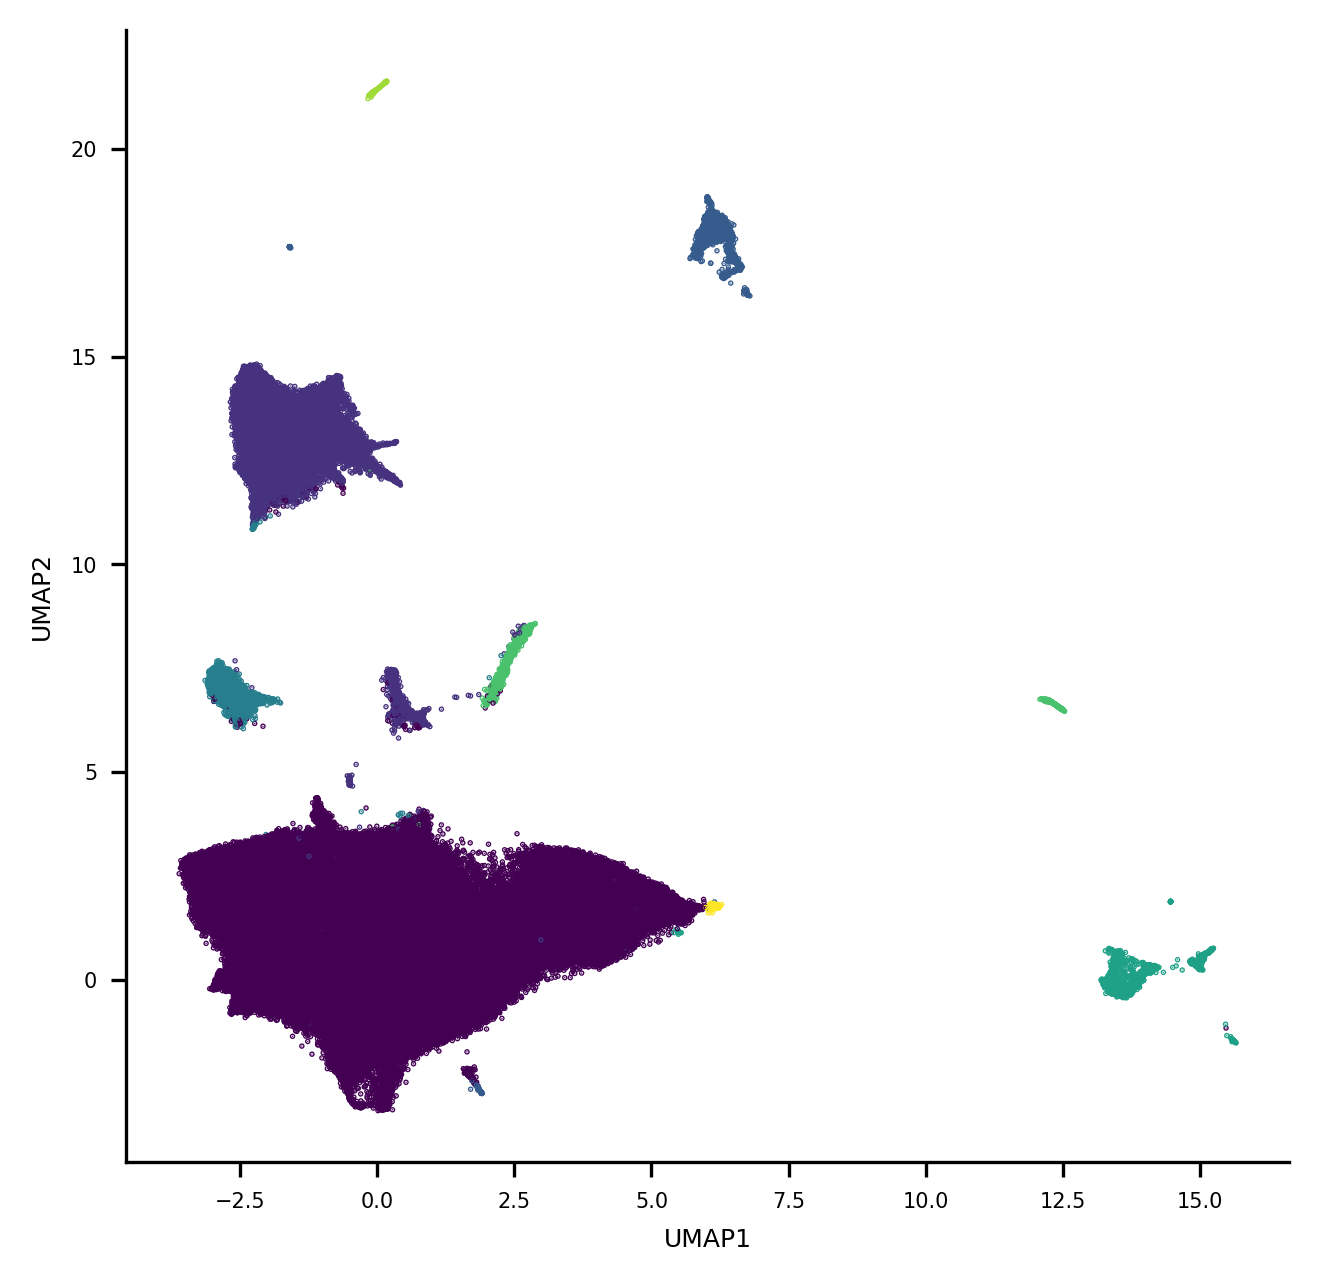

In [11]:
# --- VISUALIZE THE CLUSTERS ---


fig, axs = plt.subplots(1,1,figsize = (5,5),dpi=300)
plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=0.1,c=adata.obs["cluster"])
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
# plt.legend()
sns.despine()
plt.show()


No handles with labels found to put in legend.


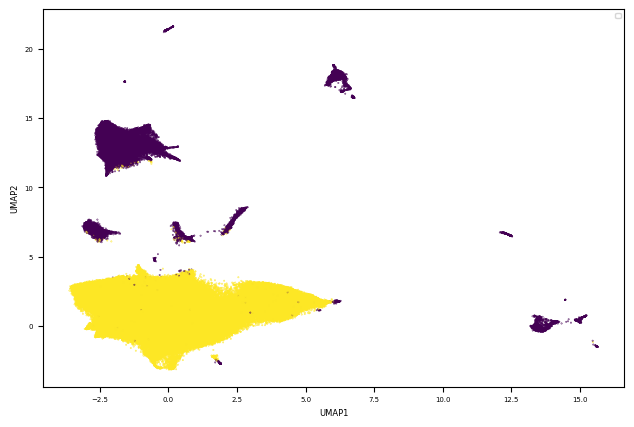

No handles with labels found to put in legend.


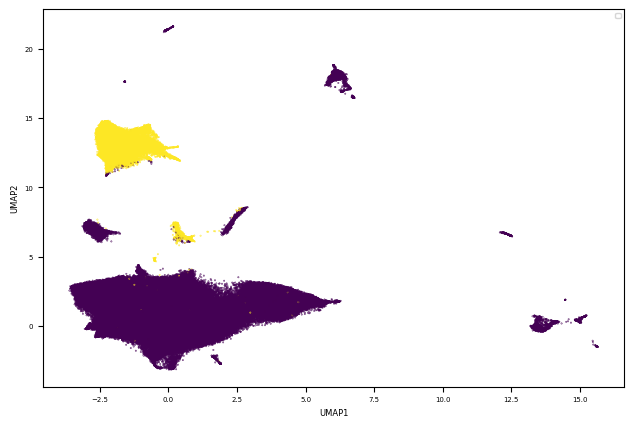

No handles with labels found to put in legend.


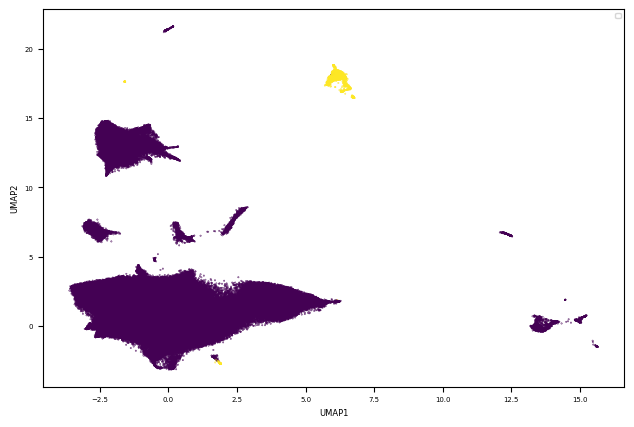

No handles with labels found to put in legend.


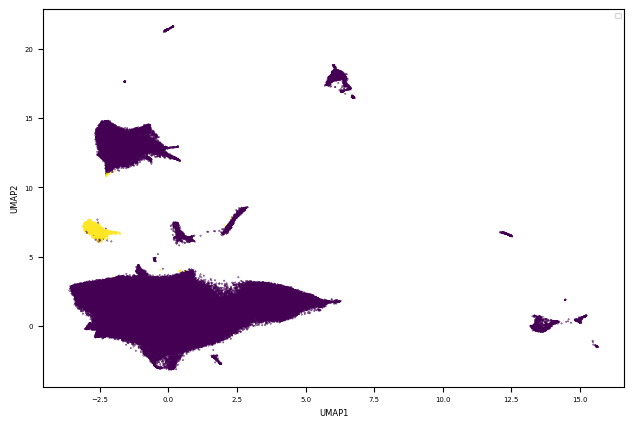

No handles with labels found to put in legend.


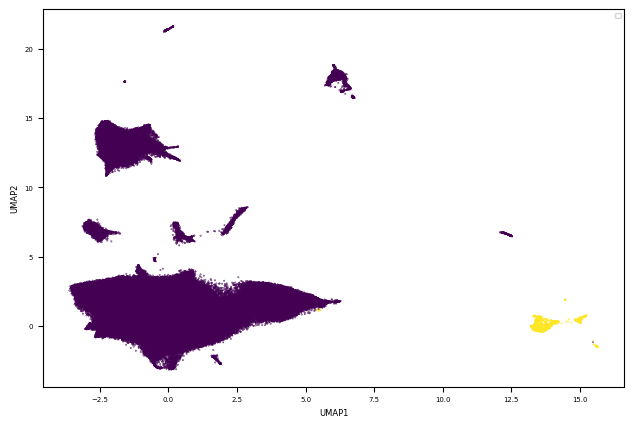

No handles with labels found to put in legend.


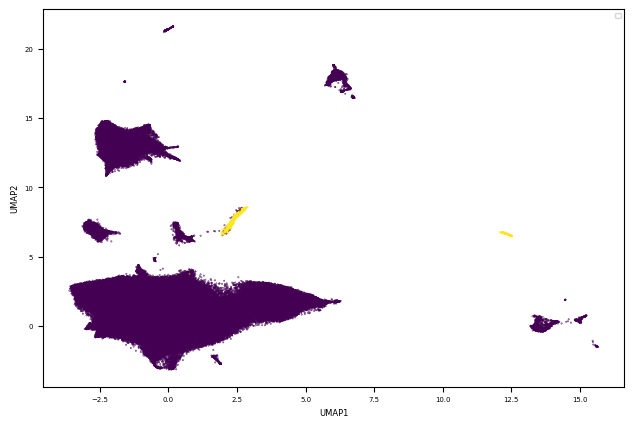

No handles with labels found to put in legend.


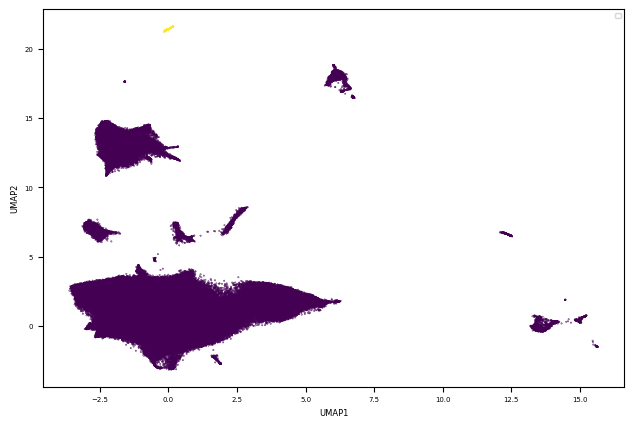

No handles with labels found to put in legend.


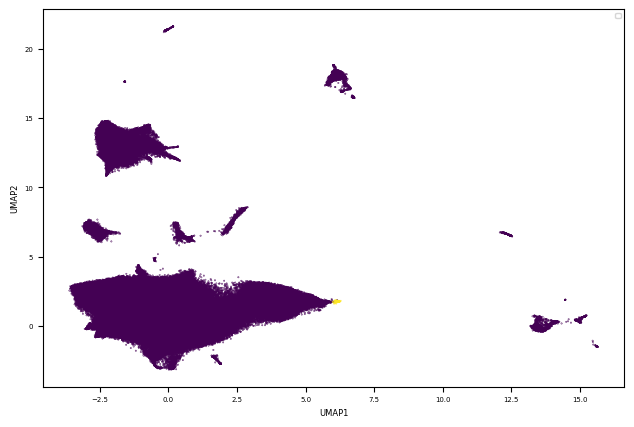

In [202]:
# --- VISUALIZE THE CLUSTERS ---

for cluster in sorted(list(adata.obs["cluster"].unique())):
    fig, axs = plt.subplots(1,1,figsize = (7.5,5),dpi=100)
    plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=0.1,c=adata.obs["cluster"] == cluster)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.legend()
    plt.show()


In [89]:

# --- LOAD MARKER GENE DICT ---
with open(marker_gene_dict_path) as file_obj:
    marker_gene_dict = eval(file_obj.read())

# get a flat list of the marker genes
marker_genes = []
for key,val in marker_gene_dict.items():
    marker_genes += val

# get the clusters
clusters = sorted(list(marker_gene_dict.keys()))

    

In [90]:
# --- MAKE THE MARKER GENE ADATA ---


# fill cluster_samples_list and pseudocell_cluster_list
cluster_samples_list = []
pseudocell_cluster_list = []
for cluster in clusters:
    
    # load samples: [num_cell_samples x num_marker_genes]
    cluster_sample_path = '%s/cluster_%s_marker_gene_samples_mat.npy' % (de_folder_out,cluster)
    cluster_samples = np.loadtxt(cluster_sample_path)
    cluster_samples_list.append(cluster_samples)
    
    # update pseudocell_cluster_list
    pseudocell_cluster_list += [cluster] * cluster_samples.shape[0]
    
# concatenate together the samples into a [(num_clusters * num_cell_samples) x num_marker_genes] array
marker_sampled_X = np.concatenate(cluster_samples_list)
    
    
# make marker_sampled_adata
marker_sampled_adata = anndata.AnnData(X = marker_sampled_X)
marker_sampled_adata.obs['cluster'] = pseudocell_cluster_list
marker_sampled_adata.var_names = marker_genes



marker_sampled_adata




AnnData object with n_obs × n_vars = 8000 × 21
    obs: 'cluster'

In [125]:
# --- MAKE CLUSTER CATEGORICAL ---
marker_sampled_adata.obs['cluster'] = marker_sampled_adata.obs['cluster'].astype('category')




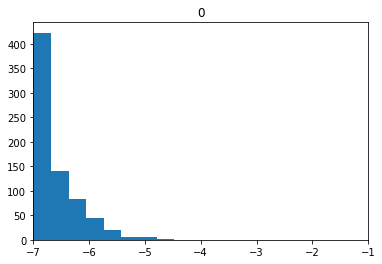

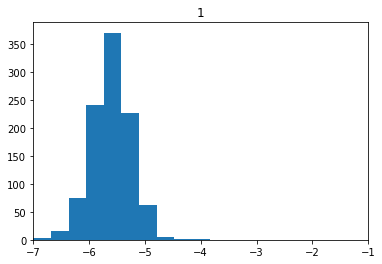

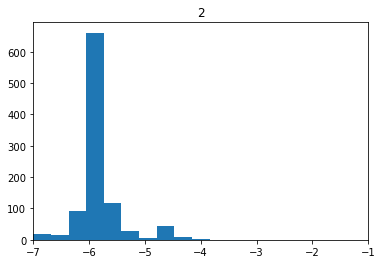

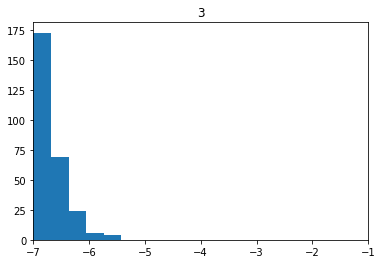

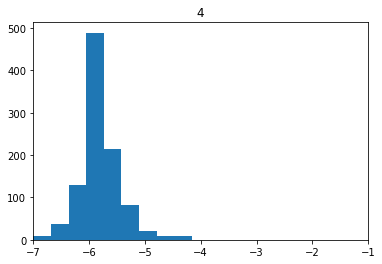

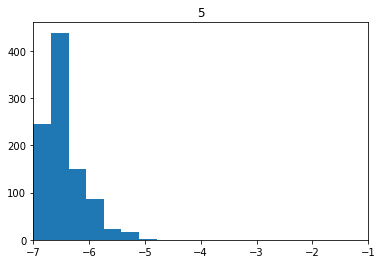

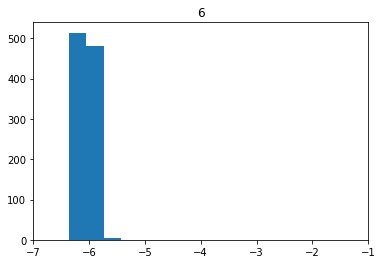

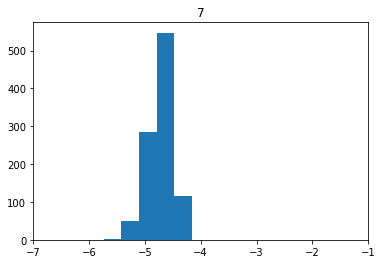

In [115]:
# --- VIZ MARKER EXPRESSION ---

for cluster in clusters:
    min_bin = -7
    max_bin = -1
    cluster_marker_sampled_adata = marker_sampled_adata[marker_sampled_adata.obs['cluster'] == cluster]
    plt.clf()
    plt.hist(np.log10(np.array(cluster_marker_sampled_adata[:,'Neurl1b'].X).flatten()),bins=np.linspace(min_bin,max_bin,20))
    plt.title(cluster)
    plt.xlim((min_bin,max_bin))
    plt.show()



In [116]:
# --- LOG10 TRANSFORM THE EXPRESSION ---


marker_sampled_adata.X = np.log10(marker_sampled_adata.X)



/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


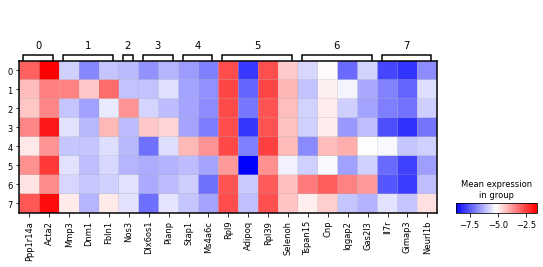

In [173]:
# --- VIZ MATRIX PLOT ---

# ** make the labels **
var_group_positions = []
var_group_labels = []
current_num_markers = 0
for cluster in clusters:
    cluster_num_markers = len(marker_gene_dict[cluster])
    var_group_positions.append([current_num_markers,current_num_markers+cluster_num_markers-1])
    current_num_markers += cluster_num_markers
    var_group_labels.append(str(cluster))
var_group_positions                       
                        
# ** make the fig **
# figsize = (14,7)
subplot_rc_dict = {**rc_params,**{'figure.figsize' : (20,7.5)}}
# with rc_context(subplot_rc_dict):
# with rc_context({'figure.figsize' : (20,2)}):
with plt.rc_context({'figure.figsize' : (3,2)}):
    scanpy.pl.matrixplot(marker_sampled_adata, marker_genes, groupby = 'cluster',cmap='bwr',
                        var_group_positions = var_group_positions,
                        var_group_labels = var_group_labels)
                   
                     

In [6]:
# --- LOAD THE FRACTION ABOVE DF ---

fraction_above_df_path = '/Users/benauerbach/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/connected/scvi_res/clustering/res_0.1/de/fraction_larger_samples_mat.tsv'
fraction_above_df = pd.read_table(fraction_above_df_path,sep='\t',index_col='cluster')
fraction_above_df



,Sox17,Mrpl15,Rb1cc1,Pcmtd1,2610203C22Rik,Cops5,Prex2,Sulf1,Tram1,Rpl7,...,mt-Co1,mt-Co2,mt-Atp8,mt-Co3,mt-Nd3,mt-Nd4l,mt-Nd4,mt-Nd5,mt-Nd6,mt-Cytb
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.4770,0.8489,0.7822,0.8369,0.6143,0.8888,0.5359,0.7501,0.5404,0.8002,...,0.8728,0.8813,0.8770,0.8969,0.8953,0.8780,0.9021,0.9082,0.8284,0.8823
1,0.4989,0.1936,0.2139,0.1750,0.4570,0.1377,0.4117,0.2237,0.5601,0.2333,...,0.1137,0.1085,0.1087,0.0857,0.0948,0.1287,0.0927,0.0885,0.1505,0.1211
2,0.9919,0.2512,0.3824,0.3812,0.2499,0.2436,0.8069,0.6407,0.4231,0.3664,...,0.2366,0.2009,0.2166,0.1750,0.1796,0.1618,0.1866,0.2120,0.2770,0.1871
3,0.2400,0.4435,0.4657,0.4109,0.2600,0.3996,0.7951,0.5182,0.4254,0.3523,...,0.4248,0.4182,0.4429,0.4408,0.4343,0.4153,0.4040,0.3802,0.4678,0.4236
4,0.5425,0.1142,0.1981,0.0733,0.7643,0.1247,0.0110,0.0044,0.3936,0.2812,...,0.1694,0.1273,0.1040,0.1423,0.1138,0.0757,0.0947,0.1058,0.1322,0.0726
5,0.2174,0.0327,0.3068,0.1698,0.0590,0.0877,0.4387,0.4189,0.0998,0.0180,...,0.3851,0.4284,0.4501,0.4102,0.4178,0.4093,0.3990,0.3683,0.4701,0.3945
6,0.8874,0.1568,0.1750,0.1098,0.1657,0.1635,0.8341,0.0140,0.1434,0.0874,...,0.1097,0.0934,0.0936,0.1078,0.1086,0.0891,0.0949,0.0921,0.1974,0.0977
7,0.9428,0.2558,0.1952,0.1562,0.4241,0.2365,0.4045,0.0614,0.0805,0.1933,...,0.3510,0.3089,0.2514,0.3465,0.2786,0.2445,0.2861,0.2898,0.4906,0.3270


In [21]:
# --- GET UP AND DOWN GENES ---
de_threshold = 0.95
up_marker_genes = np.max(fraction_above_df,axis=0)
up_marker_genes = up_marker_genes[up_marker_genes >= de_threshold].index
down_marker_genes = np.min(fraction_above_df,axis=0)
down_marker_genes = down_marker_genes[down_marker_genes <= 1 - de_threshold].index
up_marker_genes



Index(['Sox17', 'Tfap2b', 'Gsta3', 'Ptpn18', 'Neurl3', 'Il1rl1', 'Cavin2',
       'Myo1b', '1700019D03Rik', 'Cd28',
       ...
       'Il2rg', 'Cysltr1', 'Itm2a', 'Klhl4', 'Pcdh19', 'Btk', 'Bmx', 'Gpm6b',
       'Tmsb4x', 'Tlr7'],
      dtype='object', length=913)

In [23]:
# # --- GET MARKERS FOR EACH CLUSTER ---

# fraction_above_mat = np.array(fraction_above_df)
# cluster_markers = []
# num_markers_per_cluster = 5
# for cluster_index, cluster in enumerate(fraction_above_df.index):
    
#     marker_indices = np.argsort(fraction_above_mat[cluster_index,:])[-1 * num_markers_per_cluster:]
#     marker_genes = list(fraction_above_df.columns[marker_indices])
#     cluster_markers.append(marker_genes)


In [26]:
# --- LIST CONDITIONS AND CLUSTERS ---

conditions = ['female aligned bmal1-control',
             'female aligned bmal1-ko',
             'female misaligned bmal1-control',
             'male aligned bmal1-control',
             'male aligned bmal1-ko',
             'male misaligned bmal1-control']


clusters = sorted(list(adata.obs['cluster'].unique()))


In [27]:
# --- LIMIT TO GENES THAT ARE DETECTED ---

adata.var['prop'] = np.array(np.sum(adata.X,axis=0)).flatten() / np.sum(np.array(adata.obs['lib_size']))
adata = adata[:,adata.var['prop'] > 0]
adata


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


View of AnnData object with n_obs × n_vars = 145271 × 26120
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'prop'
    obsm: 'X_scVI', 'X_scVI_umap'

In [28]:
# --- COMPUTE THE PROPS OF EACH GENE IN EACH CLUSTER ---

cluster_props = np.zeros((len(clusters),adata.shape[1]))
for cluster in clusters:
    print(cluster)
    cluster_adata = adata[adata.obs['cluster'] == cluster]
    cluster_props[cluster,:] = np.array(np.sum(cluster_adata.X,axis=0)).flatten() / np.sum(cluster_adata.obs['lib_size'])

    



0


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


1


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


2
3


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


4
5
6
7


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will 

In [29]:
# --- COMPUTE THE MAX PROP'S ACROSS CLUSTERS FOR EACH GENE AND GET RID OF GENES THAT DON'T MEET THRESHOLD ---

min_gene_prop = 1e-5
max_props = np.max(cluster_props,axis=0)
gene_indices_to_keep = np.where(max_props >= 1e-5)[0]
adata = adata[:,gene_indices_to_keep]
adata


View of AnnData object with n_obs × n_vars = 145271 × 11531
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'prop'
    obsm: 'X_scVI', 'X_scVI_umap'

In [37]:
# --- TEMP: NAME MARKER GENES AND LIMIT ADATA TO THEM ---

marker_gene_dict = {
    0 : ['Ppp1r14a', 'Acta2'],
    1: ['Mmp3', 'Dnm1', 'Fbln1'],
    2: ['Nos3'],
    3: ['Dlx6os1', 'Pianp'],
    4: ['Stap1', 'Ms4a6c'],
    5: ['Rpl9', 'Adipoq', 'Rpl39', 'Selenoh'],
    6: ['Tspan15', 'Cnp', 'Iqgap2', 'Gas2l3'],
    7: ['Il7r', 'Gimap3', 'Neurl1b']
}
marker_genes = []
for key, val in marker_gene_dict.items():
    marker_genes = marker_genes + val
adata = adata[:,marker_genes]

adata

View of AnnData object with n_obs × n_vars = 145271 × 21
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'prop'
    obsm: 'X_scVI', 'X_scVI_umap'

In [38]:
# --- GET TRANSFORMED COUNTS ---
pseudocount = 1e-7
X_lib_norm = adata.X / np.array(adata.obs['lib_size']).reshape(-1,1)
X_lib_norm = np.array(X_lib_norm)
X_lib_norm[X_lib_norm == 0] = pseudocount
X_log_lib_norm = np.log10(X_lib_norm)




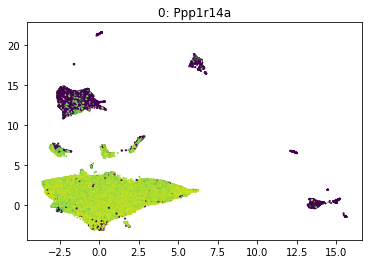

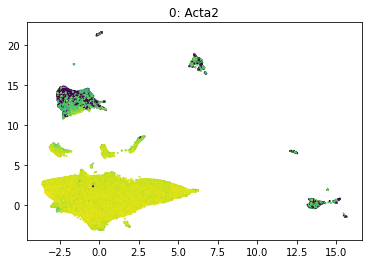

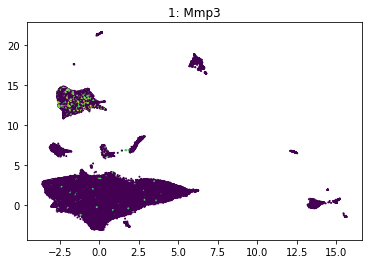

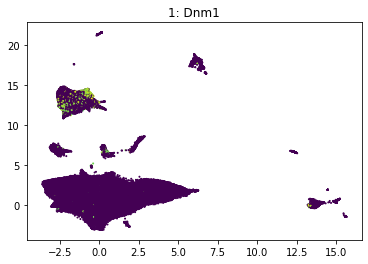

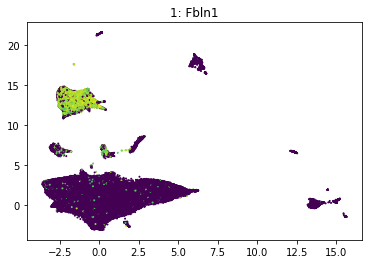

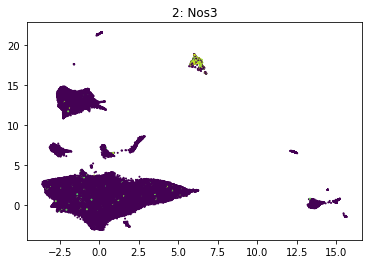

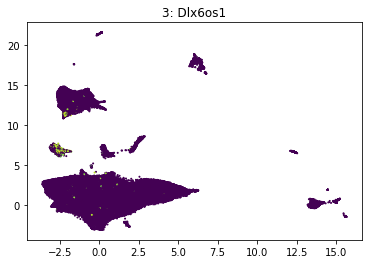

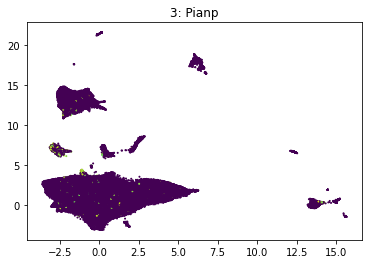

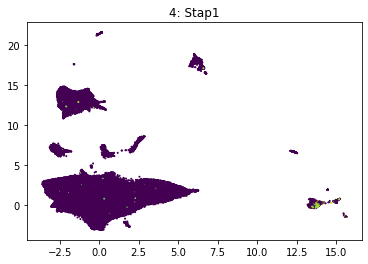

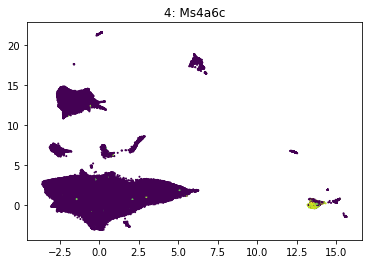

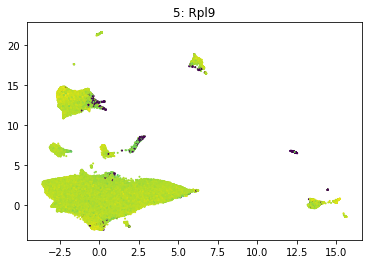

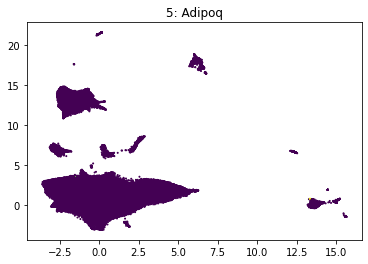

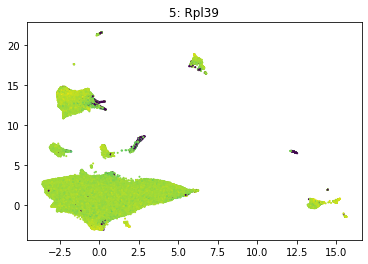

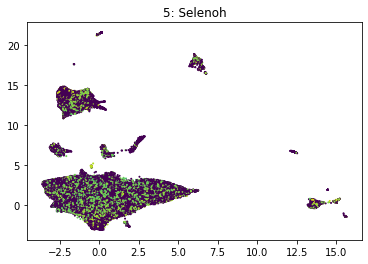

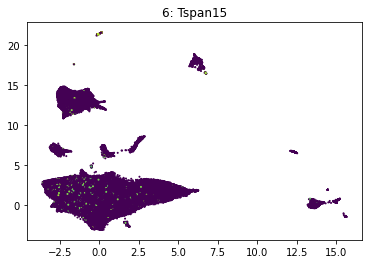

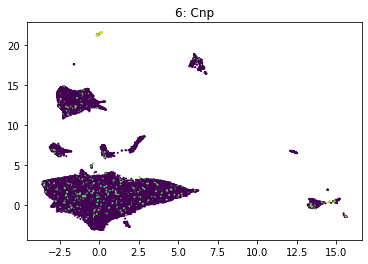

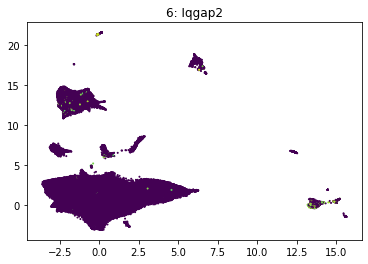

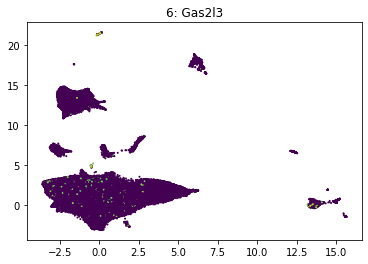

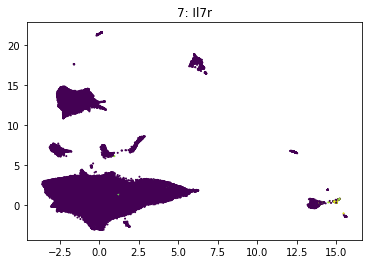

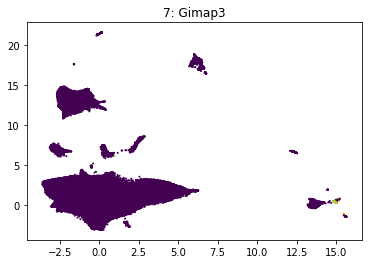

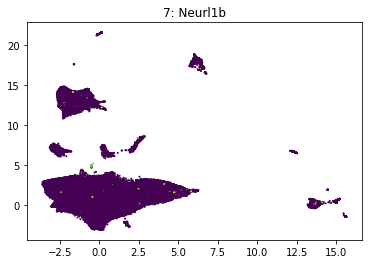

In [39]:
# --- VIZ MARKER GENES FOR EACH CLUSTER ---

for cluster_index,cluster in enumerate(clusters):

    # for gene in cluster_markers[cluster_index]:
    for gene in marker_gene_dict[cluster_index]:

        gene_X_norm = np.log10(np.array(adata[:,gene].X.todense()).flatten() / adata.obs['lib_size'] + 1e-10)

        plt.clf()
        plt.scatter(adata.obsm['X_scVI_umap'][:,0],adata.obsm['X_scVI_umap'][:,1],s=1,c=gene_X_norm)
        plt.title("%s: %s" % (cluster,gene))
        plt.show()


